# Daily LightGBM Forecasting

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000380 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1390
[LightGBM] [Info] Number of data points in the train set: 966, number of used features: 11
[LightGBM] [Info] Start training from score 1747.328748
MAE: 1660.187803056531
RMSE: 2434.323893415528


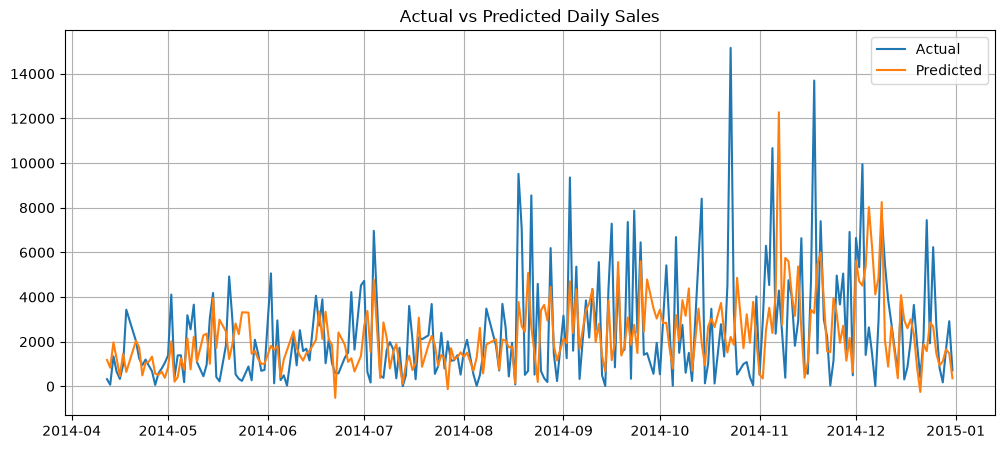

<Figure size 1200x400 with 0 Axes>

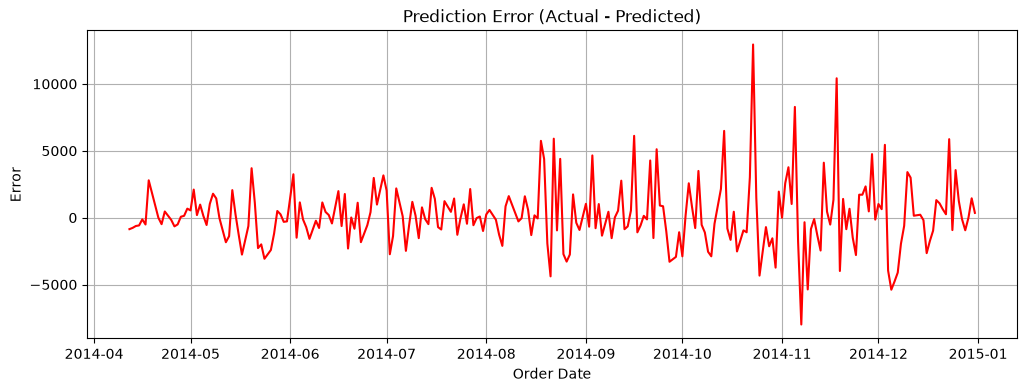

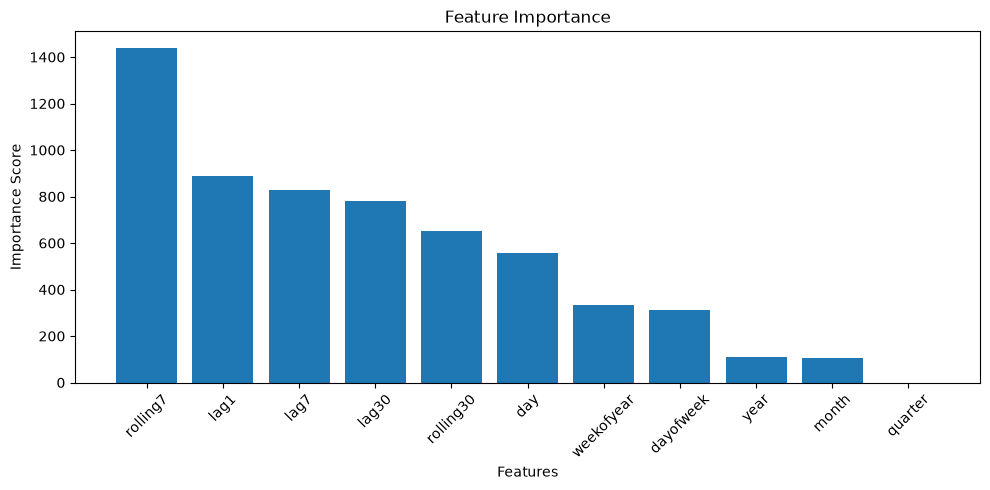

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df=pd.read_csv('../../preprocessing/daily_sales.csv')
df=df[['Order Date','Total amount']]
df['Order Date']=pd.to_datetime(df['Order Date'],format="mixed",dayfirst=True)
df=df.groupby('Order Date')['Total amount'].sum().reset_index().sort_values('Order Date').reset_index(drop=True)

df['day']=df['Order Date'].dt.day
df['month']=df['Order Date'].dt.month
df['year']=df['Order Date'].dt.year
df['dayofweek']=df['Order Date'].dt.dayofweek
df['weekofyear']=df['Order Date'].dt.isocalendar().week.astype(int)
df['quarter']=df['Order Date'].dt.quarter

df['lag1']=df['Total amount'].shift(1)
df['lag7']=df['Total amount'].shift(7)
df['lag30']=df['Total amount'].shift(30)
df['rolling7']=df['Total amount'].rolling(7).mean()
df['rolling30']=df['Total amount'].rolling(30).mean()
df=df.dropna().reset_index(drop=True)

features=['day','month','year','dayofweek','weekofyear','quarter','lag1','lag7','lag30','rolling7','rolling30']
X=df[features]
y=df['Total amount']

split=int(len(df)*0.8)
X_train,X_test=X.iloc[:split],X.iloc[split:]
y_train,y_test=y.iloc[:split],y.iloc[split:]
test_dates=df['Order Date'].iloc[split:]

model=LGBMRegressor(random_state=42,n_estimators=200,learning_rate=0.05)
model.fit(X_train,y_train)

pred=model.predict(X_test)

print('MAE:',mean_absolute_error(y_test,pred)) #type:ignore
print('RMSE:',np.sqrt(mean_squared_error(y_test,pred))) #type:ignore

plt.figure(figsize=(12,5))
plt.plot(test_dates,y_test.values,label='Actual') #type:ignore
plt.plot(test_dates,pred,label='Predicted') #type:ignore
plt.legend()
plt.title('Actual vs Predicted Daily Sales')
plt.grid(True)
plt.show()

plt.figure(figsize=(12,4))
# Prediction Error Plot
errors = y_test.to_numpy() - pred

plt.figure(figsize=(12,4))
plt.plot(test_dates, errors, color="red")
plt.title("Prediction Error (Actual - Predicted)")
plt.xlabel("Order Date")
plt.ylabel("Error")
plt.grid(True)
plt.show()

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

joblib.dump(model,'../../stub_service/lightgbm_daily_model.pkl')
